In [1]:
# ---------------------------------------------------------------
# Script to Generate Scatter Plot of Observed Time Series by Age
# Comparison between my estimations and DHS Data
# Created by Felipe Sanchez
# Date: May 23, 2024
# ---------------------------------------------------------------

# Import necessary packages
using Turing
using MCMCChains
using Distributions
using RData
using CSV
using XLSX
using DataFrames
using LinearAlgebra
using StatsFuns
using Random
using Serialization
using CairoMakie
using AlgebraOfGraphics
using Plots
using StatsPlots
using Gadfly
using KernelDensity
using Colors
using CategoricalArrays

# Ensure all required modules are imported from each package
using AlgebraOfGraphics: density
using DataFrames: stack
using CairoMakie: violin

# Define directory path for data input and output
dir = "/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Fertility/ModellingF/Output/"

# ---------------------------------------------------------------
# Note:
# - This script uses various packages for statistical analysis,
#   data manipulation, and visualization.
# - Ensure all listed packages are installed in your Julia environment.
# - AMBA Average Mortality by Age and after one by year after the age-group 25-29 and so on
# ---------------------------------------------------------------

# Add further code for your data analysis and visualization below this line


"/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Fertility/ModellingF/Output/"

In [2]:
#Fertility
lmuf = deserialize("/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Fertility/ModellingF/Data_Created/lmu.jls")
#Mortality
lmum = deserialize("/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Mortality/ModellingM/Data_Created/lmu.jls")
#Fertility DHS


8-element Vector{DataFrame}:
 11×21 DataFrame
 Row │ 1         2         3         4         5         6         7         8 ⋯
     │ Float64   Float64   Float64   Float64   Float64   Float64   Float64   F ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ -7.37662  -6.84376  -6.5514   -6.24822  -5.85257  -5.85072  -5.69847  - ⋯
   2 │ -7.5609   -6.90446  -6.50059  -6.14931  -5.90058  -5.88722  -5.64622  -
   3 │ -7.51388  -6.93676  -6.38828  -6.13962  -5.83885  -5.83885  -5.9993   -
   4 │ -7.21144  -6.93133  -6.64866  -6.34731  -6.18493  -6.0542   -5.92655  -
   5 │ -6.94483  -6.60866  -6.25896  -6.12316  -5.90953  -5.72309  -5.66962  - ⋯
   6 │ -6.60457  -6.31702  -6.00347  -5.68721  -5.60749  -5.39543  -5.2462   -
   7 │ -6.2023   -5.93112  -5.84086  -5.6255   -5.49465  -5.34135  -5.30898  -
   8 │ -5.59902  -5.316    -5.29612  -5.08486  -5.01498  -4.86473  -4.83084  -
   9 │ -5.17905  -4.92339  -4.74363  -4.55371  -4.43509  -4.38044  -4.39541

In [3]:
lmum[1] #is a 11×21 DataFrame. Is ths log of mortality rate for undeducated males.  DataFrame where the rows are the ages 25-29, 30-34, 35-39, 40-44, 45-49, 50-54,55-59, 60-64, 65-69, 70-74, 75+  and the columns the years 1998 until 2018
lmuf[1] #6×21 DataFrame where the rows are the ages 25-29, 30-34, 35-39, 40-44, 45-49, 50-55 and the columns the years 1998 until 2018

Row,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,-2.28348,-1.74313,-1.34123,-1.08856,-0.874669,-0.711989,-0.611906,-0.640383,-0.751759,-0.835812,-2.75338,-2.81874,-2.84126,-2.6406,-2.62957,-2.54984,-2.59989,-2.77164,-2.92501,-2.85867,-3.07855
2,-2.74727,-2.15064,-1.69292,-1.37625,-1.16964,-1.0034,-0.912166,-0.981299,-1.13067,-1.26883,-3.0398,-3.13053,-3.20038,-3.09592,-3.09393,-3.07193,-3.09712,-3.23037,-3.3753,-3.29565,-3.39473
3,-3.21719,-2.63452,-2.20826,-1.93834,-1.72525,-1.62587,-1.59136,-1.66907,-1.88862,-2.05445,-3.70674,-3.76087,-3.78765,-3.48632,-3.3808,-3.28488,-3.26442,-3.38086,-3.50928,-3.54691,-3.82013
4,-4.33199,-3.96552,-3.59134,-3.37923,-3.22303,-3.03431,-2.8837,-2.85755,-2.8729,-2.89016,-4.34309,-4.34006,-4.34785,-4.20838,-4.15472,-4.14399,-4.26958,-4.34273,-4.54139,-4.62487,-4.85914
5,-6.3938,-6.06604,-5.69712,-5.47997,-5.32899,-5.23891,-5.12886,-5.0317,-5.05778,-5.30335,-6.29491,-6.40675,-6.57956,-6.45497,-6.60539,-6.29787,-6.50089,-6.73997,-6.73618,-6.64629,-6.92203
6,-8.9823,-8.57081,-8.11369,-8.11416,-8.27097,-7.78592,-7.41639,-7.2129,-7.78988,-8.01898,-8.88963,-8.9917,-8.9213,-8.91998,-8.84188,-8.83662,-9.27193,-9.38193,-8.36126,-10.0557,-8.86543


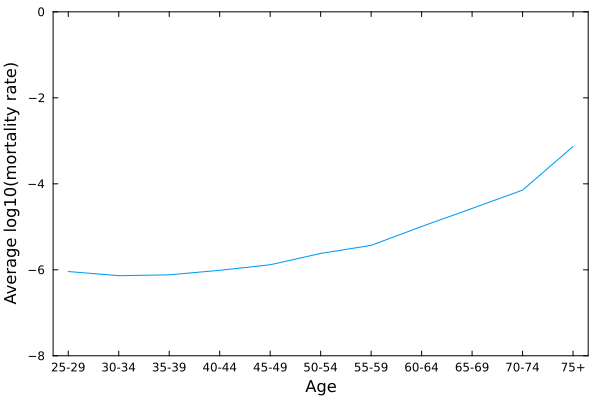

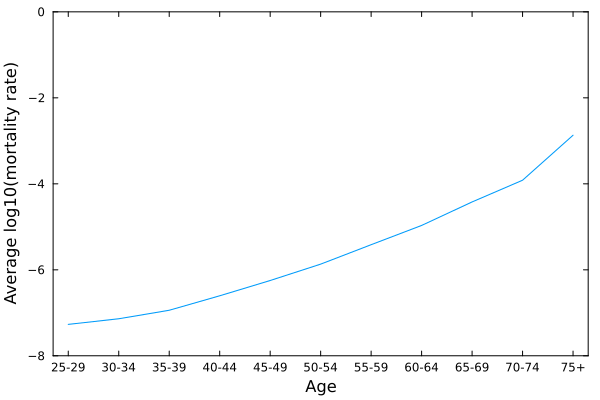

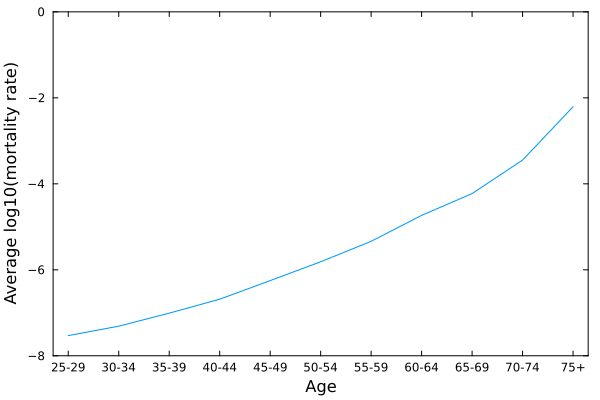

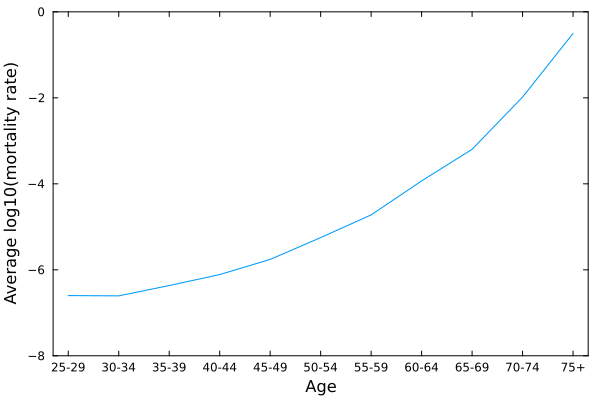

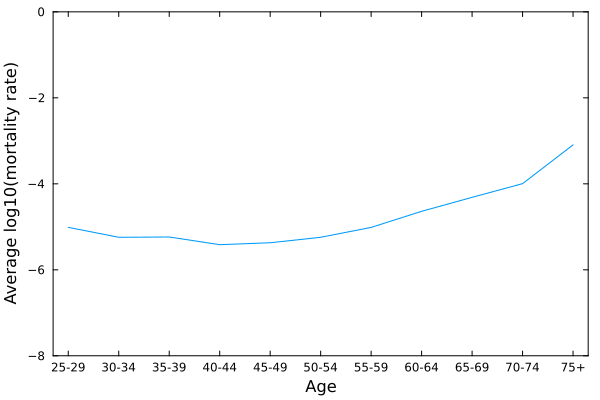

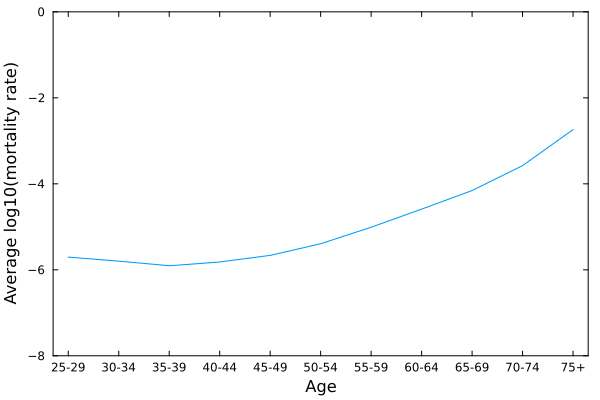

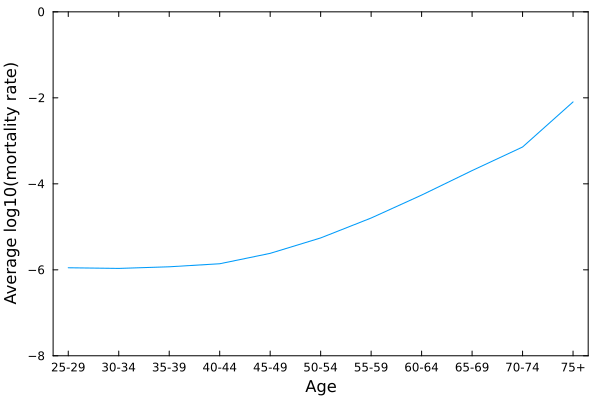

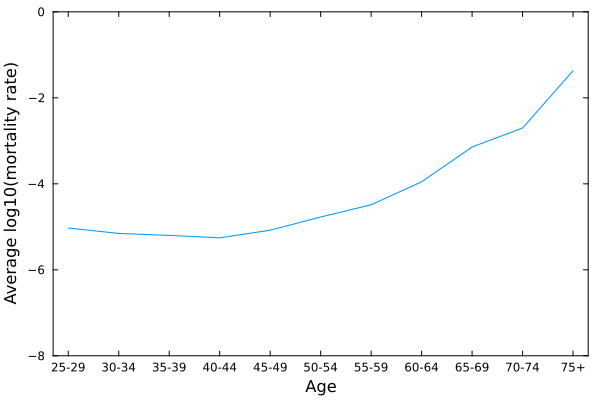

In [11]:
# Define the ages and years
ages = ["25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75+"]
years = 1998:2018

# Function to plot average log mortality rate
function plot_average_log_mortality(lmum_matrix, index)
    # Create the DataFrame from the matrix with automatically generated column names
    lmum_df = DataFrame(lmum_matrix, :auto)

    # Add the 'Age' column after transposing the matrix
    lmum_df = hcat(DataFrame(Age=ages), lmum_df)

    # Rename the columns to have 'Age' and years as column names
    rename!(lmum_df, Symbol.(["Age"; string.(years)]))

    # Convert to long format for easier manipulation
    lmum_long = stack(lmum_df, Not(:Age), variable_name=:Year, value_name=:log_mortality_rate)

    # Convert 'Year' to integer and 'Age' to categorical
    lmum_long.Year = parse.(Int, lmum_long.Year)
    lmum_long.Age = categorical(lmum_long.Age)

    # Calculate the average log mortality rate for each age group
    average_log_mortality_rate = combine(groupby(lmum_long, :Age), :log_mortality_rate => mean => :average_log_mortality_rate)

    # Convert 'Age' to categorical for plotting
    average_log_mortality_rate.Age = categorical(average_log_mortality_rate.Age)

    # Create the plot
    p = Plots.plot(average_log_mortality_rate.Age, average_log_mortality_rate.average_log_mortality_rate, 
                   linewidth=1.05, 
                   xlabel="Age", ylabel="Average log10(mortality rate)", 
                   legend=false, 
                   ylim=(-8, 0))

    # Customize the theme
    Plots.plot!(p, xtickfont=font(8, "sans-serif", rotation=90), yticks=:auto, grid=false, framestyle=:box)

    # Display the plot
    display(p)

    # Save the plot to a file
    savefig(p, "/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Mortality/ModellingM/Output/amba/amba_lmum" * string(index) * ".png")
end

# Iterate over lmum[1] to lmum[8]
for i in 1:8
    lmum_matrix = Matrix(lmum[i])
    plot_average_log_mortality(lmum_matrix, i)
end

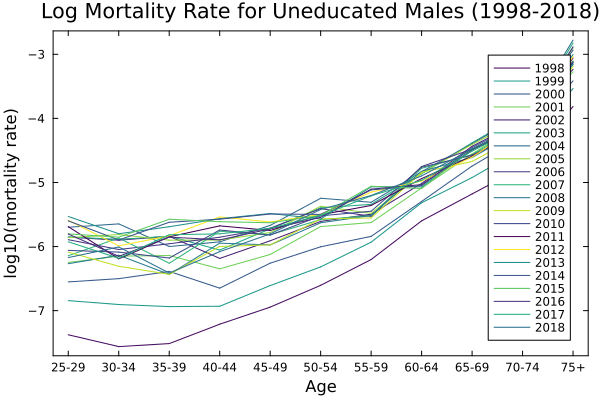

"/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Mortality/ModellingM/Output/amba/lmum1.png"

In [4]:
using DataFrames
using Plots
using Colors
using CategoricalArrays

# Define the ages and years
ages = ["25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75+"]
years = 1998:2018

# Assuming lmum[1] is your DataFrame containing the log mortality rates as a 11×21 DataFrame
# Transpose the matrix and create a new DataFrame
lmum1_matrix = Matrix(lmum[1])

# Create the DataFrame from the matrix with automatically generated column names
lmum1_df = DataFrame(lmum1_matrix, :auto)

# Add the 'Age' column after transposing the matrix
lmum1_df = hcat(DataFrame(Age=ages), lmum1_df)

# Rename the columns to have 'Age' and years as column names
rename!(lmum1_df, Symbol.(["Age"; string.(years)]))

# Convert to long format for easier plotting
lmum1_long = stack(lmum1_df, Not(:Age), variable_name=:Year, value_name=:log_mortality_rate)

# Convert 'Year' to integer and 'Age' to categorical
lmum1_long.Year = parse.(Int, lmum1_long.Year)
lmum1_long.Age = categorical(lmum1_long.Age)

# Define the viridis color palette
viridis_colors = cgrad(:viridis, rev=false)

# Create the plot
p = Plots.plot(lmum1_long.Age, lmum1_long.log_mortality_rate, group=lmum1_long.Year, color=lmum1_long.Year, 
         linewidth=1.05, palette=viridis_colors, 
         xlabel="Age", ylabel="log10(mortality rate)", 
         title="Log Mortality Rate for Uneducated Males (1998-2018)",
         legend=:right)

# Customize the theme
Plots.plot!(p, xtickfont=font(8, "sans-serif", rotation=90), yticks=:auto, grid=false, framestyle=:box)

# Display the plot
display(p)

# Save the plot to a file
savefig(p, "/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Mortality/ModellingM/Output/amba/lmum1.png")
